# Lecture 1 - Introduction to the Vacuum World

In this notebook we will introduce the concept of `environment`, `agent` and we will try to compare a `random_agent` against a simple `reflex agent`.

In [9]:
# this is something we will run each time at the beginning of our notebook
# in order to access the modules present in scripts
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

# and then we import the module as scripts.module_name
from scripts.environment import *
from scripts.agent import RandomAgent
from scripts.runner import run_episode, human_testing

import inspect

## Environment

An **environment** is the world or setting in which an agent operates. It provides percepts (observations) to the agent through sensors and changes its internal state in response to the actions performed by the agent's actuators. 

In Artificial Intelligence (specifically following Russell & Norvig's *AIMA* framework), environments are typically classified along key dimensions:

* **Discrete vs. Continuous:** Whether the states, time, or actions are distinct steps or smooth variables.
* **Fully vs. Partially Observable:** Whether the agent's sensors give complete access to the state of the environment at any given time.
* **Deterministic vs. Stochastic:** Whether the next state is completely determined by the current state and action.
* **Static vs. Dynamic:** Whether the environment can change while the agent is deliberating.

### The Vacuum World

During our tutoring lectures we will work in the Vacuum World, a simple grid environment where our agent is a vacuum cleaner and our goal is to clean the whole house. The environment will have various levels of difficulty. In the simplest (0), there are only 2 available floor cells, one dirty and the other clean. Increasing the level increases the number of rooms, the number of possible obstacles in the way (both static and dynamic!), and can even change the cleaning behavior (not all dust is the same).

Today we will work with difficulty 0. As mentioned, there are 2 total available cells.

* The blue dot represents the vacuum cleaner.
* The light brown dot represents the dirt.

The vacuum cleaner can perform up to 6 different actions:

0. Up (not applicable in difficulty 0)
1. Down (not applicable in difficulty 0)
2. Left
3. Right
4. Idle
5. Suck

When a non-legal action is selected (e.g., trying to move into a wall or out of bounds), the vacuum remains in its current position, but the action is penalized.

For future work the environment already has a proxy reward systems (that we will improve in order to make it possible to do reward shaping). 

* Valid Movement (Up, Down, Left, Right): $-0.1$
* Illegal Movement: $-3.0$
* Idle: $-0.5$ 
* Suck Clean Tile: $-1.0$ 
* Suck Dirty Tile: $+10.0$
* Goal Reached: $+100.0$ bonus when all dirt is cleaned (is_goal() == True), terminating the episode (terminated = True).

Additionally, if the agent reaches the step limit (total_step >= max_step), the episode ends via truncation (truncated = True).

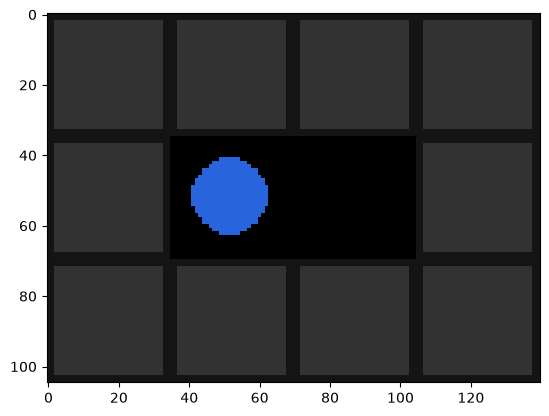

In [10]:
env = VacuumWorld(render_mode=RenderMode.RGB_ARRAY, observation_type=ObservationType.IMAGE, difficulty=0)
frame = env._get_obs()

from matplotlib import pyplot as plt

plt.imshow(frame)
plt.show()

Now, I'll let you try the environment before going on.

The keys binding for human is:

* Q to suck
* WASD to move 
* nothing to idle

In [11]:
from scripts.runner import human_testing

env = VacuumWorld()
human_testing(env)

## Agent

An agent, as defined in chapter 2.1 of the *Artificial Intelligence: A Modern Approach* book, is anything that can perceive its environment through sensors, and act upon that environment through actuators based on its agent program. This can be a dog, a robot, or even you. As long as you can perceive the environment and act on it, you are an agent. This notebook will explain how to implement a simple agent, create an environment, and implement a program that helps the agent act on the environment based on its percepts.

We will use object of the class `Agent`. Let's import it.

### Random Agent

A random agent program, as the name suggests, chooses an action at random, without taking into account the percepts.\
Here, we will demonstrate a random vacuum agent for a trivial vacuum environment, that is, the two-state environment.

In [12]:
print(inspect.getsource(RandomAgent))

class RandomAgent(Agent):
    """Random agent."""

    def __init__(self, env : gym.Env):
        """Just take the actions from the enviornment as basic knowledge"""
        self.action_space = env.action_space

    def act(self, observation: Any):
        """Observation are not actually used"""
        return self.action_space.sample()



So, what does our `RandomAgent` do?\
Well pretty much it initializes itself by taking down the possible actions (all) and once it has to act it just acts randomly.

Don't be scared by the `gym.Env`: in this serie of notebooks we will use the **Gymnasium Protocol**, a well established protocol to deal with agents (especially in Reinforcement Learning Scenarios, but we will adapt it). You can find more about it in [this documentation here](https://gymnasium.farama.org/introduction/basic_usage/).

So don't bother it and let's see the agent in action!

We will render the scene with PyGame. Personally I find it really enjoyable, maybe look at its [documentation here](https://www.pygame.org/docs/).

In [13]:
env = VacuumWorld()
agent = RandomAgent(env)
run_episode(env, agent)

78.3

### Simple Reflex Agent

A simple reflex agent program selects actions on the basis of the current percept, ignoring the rest of the percept history.\
These agents work on a condition-action rule (also called situation-action rule, production or if-then rule), which tells the agent the action to trigger when a particular situation is encountered.